# QLoRA Evaluation Analysis
Compare the base pipeline against the fine-tuned QLoRA adapter using the unified experiment table.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_PATH = Path("../experiments/all_results.csv")
METRICS = [
    "faithfulness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

results = pd.read_csv(RESULTS_PATH)
comparison = results[results["variant"].isin(["full_pipeline", "finetuned_pipeline"])].copy()
comparison = comparison.set_index("variant").reindex(["full_pipeline", "finetuned_pipeline"])

if comparison.dropna(how="all").empty:
    raise ValueError("No base or fine-tuned rows were found in experiments/all_results.csv.")

available_metrics = [metric for metric in METRICS if metric in comparison.columns]
if not available_metrics:
    raise ValueError("No RAGAS metrics are available in experiments/all_results.csv.")

comparison[available_metrics]

,faithfulness,answer_relevancy,context_precision,context_recall
variant,,,,
full_pipeline,0.7517,0.1961,0.1432,0.1432
finetuned_pipeline,0.7517,0.1961,0.1432,0.1432


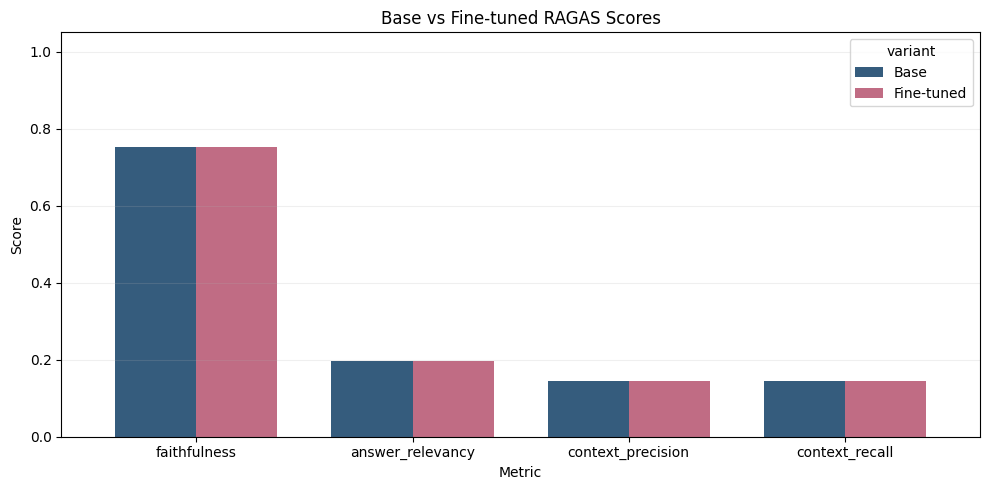

In [5]:
plot_df = comparison[available_metrics].T.rename(
    columns={
        "full_pipeline": "Base",
        "finetuned_pipeline": "Fine-tuned",
    }
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#355C7D", "#C06C84"],
    width=0.75,
)
ax.set_title("Base vs Fine-tuned RAGAS Scores")
ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
base_faithfulness = comparison.loc["full_pipeline", "faithfulness"] if "faithfulness" in comparison.columns else None
finetuned_faithfulness = comparison.loc["finetuned_pipeline", "faithfulness"] if "faithfulness" in comparison.columns else None

if pd.isna(base_faithfulness) or pd.isna(finetuned_faithfulness):
    print("Faithfulness comparison is not available yet. Run the finetuned evaluation to populate experiments/ablation_qlora.csv and refresh experiments/all_results.csv.")
else:
    delta = finetuned_faithfulness - base_faithfulness
    print(f"Base faithfulness: {base_faithfulness:.4f}")
    print(f"Fine-tuned faithfulness: {finetuned_faithfulness:.4f}")
    print(f"Delta: {delta:+.4f}")
    if delta > 0:
        print("Faithfulness improved with the fine-tuned adapter.")
    elif delta < 0:
        print("Faithfulness decreased with the fine-tuned adapter.")
    else:
        print("Faithfulness is unchanged.")

Base faithfulness: 0.7517
Fine-tuned faithfulness: 0.7517
Delta: +0.0000
Faithfulness is unchanged.
